<h1 align="center">Phishing URL Dataset Overview</h1>

[← Go back to Documentation page](README.md)

This notebook documents the dataset used by the phishing website detection system. It is intentionally read-only: it profiles the training and testing Parquet files, describes the target distribution, and summarizes the feature groups used by the application.

Model training, evaluation metrics, redundant-feature persistence, and serialized model creation belong to `app/generate_models.py`; this notebook does not create or update model, metric, JSON, or pickle artifacts.

In [164]:
import pandas as pd

%run "../utils/notebook_utils.py"
%run "../utils/feature_categories.py"

## Dataset Contents

This section introduces the source tables used by the profiling workflow and confirms that the training and testing splits have a compatible structure. The analysis keeps the original feature values intact so that the results can be inspected and reproduced.

The application reads precomputed features from Parquet files. The training and testing files share the same schema; `status` is the binary target, with `phishing` and `legitimate` as its source labels.

The table below reports the number of observations and columns available in each split. These dimensions provide the baseline for the remaining data-quality and feature-selection checks.

In [165]:
TRAINING_DATA = "../data/Training.parquet"
TESTING_DATA = "../data/Testing.parquet"
TARGET = "status"

training_data_frame = pd.read_parquet(TRAINING_DATA, engine="pyarrow")
testing_data_frame = pd.read_parquet(TESTING_DATA, engine="pyarrow")
full_data_frame = training_data_frame

schema_summary = pd.DataFrame({
    "rows": [len(training_data_frame), len(testing_data_frame)],
    "columns": [training_data_frame.shape[1], testing_data_frame.shape[1]],
}, index=["training", "testing"])
schema_summary

,rows,columns
training,7658,89
testing,3772,89


## Dataset Statistics

This section examines the shape and reliability of the feature table before any feature reduction is applied. The summaries cover descriptive statistics, the target distribution, missing values, data types, and the distinction between binary and higher-cardinality attributes.

These checks help identify unusual values or quality issues that could affect downstream feature engineering and model interpretation. They are exploratory only: no model is fitted and no dataset values are modified.

In [166]:
url_columns = [
    column
    for column in training_data_frame.columns
    if column.lower() in {"url", "link", "website"}
]

training_data_frame.drop(
    columns=url_columns,
    errors="ignore",
).describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
length_url,7658.0,NaN,NaN,NaN,61.031993,58.652024,12.0,32.0,47.0,70.0,1641.0
length_hostname,7658.0,NaN,NaN,NaN,20.998694,10.207985,4.0,15.0,19.0,24.0,213.0
ip,7658.0,NaN,NaN,NaN,0.148211,0.355332,0.0,0.0,0.0,0.0,1.0
nb_dots,7658.0,NaN,NaN,NaN,2.468399,1.378526,1.0,2.0,2.0,3.0,24.0
nb_hyphens,7658.0,NaN,NaN,NaN,1.003265,2.055865,0.0,0.0,0.0,1.0,32.0
...,...,...,...,...,...,...,...,...,...,...,...
web_traffic,7658.0,NaN,NaN,NaN,867966.506007,2016619.15063,0.0,0.0,2161.5,382220.0,10745722.0
dns_record,7658.0,NaN,NaN,NaN,0.021154,0.143908,0.0,0.0,0.0,0.0,1.0
google_index,7658.0,NaN,NaN,NaN,0.529381,0.499169,0.0,0.0,1.0,1.0,1.0
page_rank,7658.0,NaN,NaN,NaN,3.19274,2.542354,0.0,1.0,3.0,5.0,10.0


### Target Balance

The `status` column is the prediction target for the detection system. Comparing class counts and percentages across the training and testing splits makes it possible to check whether phishing and legitimate examples are represented consistently.

A large imbalance can affect how model performance should be interpreted, while a noticeably different split composition may indicate that evaluation results are not directly comparable to training behavior.

In [167]:
target_summary = pd.concat(
    {
        "training": training_data_frame[TARGET].value_counts(normalize=False),
        "testing": testing_data_frame[TARGET].value_counts(normalize=False),
    },
    axis=1,
).fillna(0).astype(int)
target_summary["training_percent"] = (
    target_summary["training"] / target_summary["training"].sum() * 100
).round(2)
target_summary["testing_percent"] = (
    target_summary["testing"] / target_summary["testing"].sum() * 100
).round(2)
target_summary

,training,testing,training_percent,testing_percent
status,,,,
legitimate,3829,1886,50.0,50.0
phishing,3829,1886,50.0,50.0


### Missing Values and Data Types

This quality summary records each feature's data type, missing-value count in both splits, and number of distinct training values. Sorting by missingness brings potentially incomplete inputs to the top, while the uniqueness count helps distinguish identifiers, binary flags, and continuous measurements.

The results provide context for deciding whether a feature needs special handling before it is used by a classifier.

In [168]:
data_quality_summary = pd.DataFrame({
    "dtype": training_data_frame.dtypes.astype(str),
    "missing_training": training_data_frame.isna().sum(),
    "missing_testing": testing_data_frame.isna().sum(),
    "unique_training": training_data_frame.nunique(),
}).sort_values(["missing_training", "unique_training"], ascending=[False, True])
data_quality_summary.head(20)

,dtype,missing_training,missing_testing,unique_training
nb_or,int64,0,0,1
ratio_nullHyperlinks,int64,0,0,1
ratio_intRedirection,int64,0,0,1
ratio_intErrors,int64,0,0,1
submit_email,int64,0,0,1
sfh,int64,0,0,1
ip,int64,0,0,2
nb_tilde,int64,0,0,2
nb_star,int64,0,0,2
nb_dslash,int64,0,0,2


### Boolean Attributes

Boolean attributes have exactly two observed values and commonly represent the presence or absence of a URL or webpage characteristic. Listing them separately makes the rule-like signals in the dataset easier to inspect and compare with the continuous features below.

In [169]:
BOOLEAN_ATTRIBUTES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() == 2)]. columns
)

pd.DataFrame(BOOLEAN_ATTRIBUTES, columns=["boolean_features"])

,boolean_features
0,external_favicon
1,status
2,https_token
3,shortening_service
4,empty_title
5,nb_dslash
6,right_clic
7,iframe
8,suspecious_tld
9,ip


### Non-Boolean Attributes

Non-boolean attributes contain more than two distinct values. This group includes numeric measurements, counts, and URL-like values that capture more varied behavior than a yes-or-no indicator.

Reviewing these features separately helps clarify the range of representations present in the dataset and highlights columns that may require different preprocessing or interpretation.

In [170]:
NON_BOOL_ATTRIBUTES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() > 2)].columns
)

pd.DataFrame(NON_BOOL_ATTRIBUTES, columns=["non_boolean_features"])

,non_boolean_features
0,length_hostname
1,shortest_word_path
2,safe_anchor
3,nb_hyphens
4,web_traffic
5,nb_underscore
6,nb_redirection
7,nb_comma
8,length_url
9,ratio_extRedirection


## Removing Redundant Attributes

Feature reduction removes columns that add little or no independent information for distinguishing phishing from legitimate URLs. The notebook records each removal reason so that the resulting feature set remains explainable and can be audited later.

### Constant Features

The checks below proceed from the simplest case, constant columns, to relationships between features and the target.

In [171]:
CONSTANT_REDUNDANT_FEATURES = set(
    full_data_frame.loc[:, (full_data_frame.nunique() == 1)].columns
)

pd.DataFrame(
    CONSTANT_REDUNDANT_FEATURES,
    columns=["constant_redundant_features"]
)

,constant_redundant_features
0,ratio_intRedirection
1,nb_or
2,submit_email
3,sfh
4,ratio_intErrors
5,ratio_nullHyperlinks


The constant columns identified above are removed from the working feature list because they contain no variation across the profiled URLs. Removing them reduces unnecessary dimensionality without discarding information that could separate the two target classes.

In [172]:
RELEVANT_FEATURES = set(full_data_frame.columns) - CONSTANT_REDUNDANT_FEATURES

### Highly Correlated Features

Highly correlated columns may encode nearly the same signal. The correlation matrix provides a visual overview of these relationships and helps identify groups where retaining every feature could add redundancy without adding much predictive information.

The matrix is calculated after constant features have been removed, so the remaining relationships reflect features that still vary across the dataset.

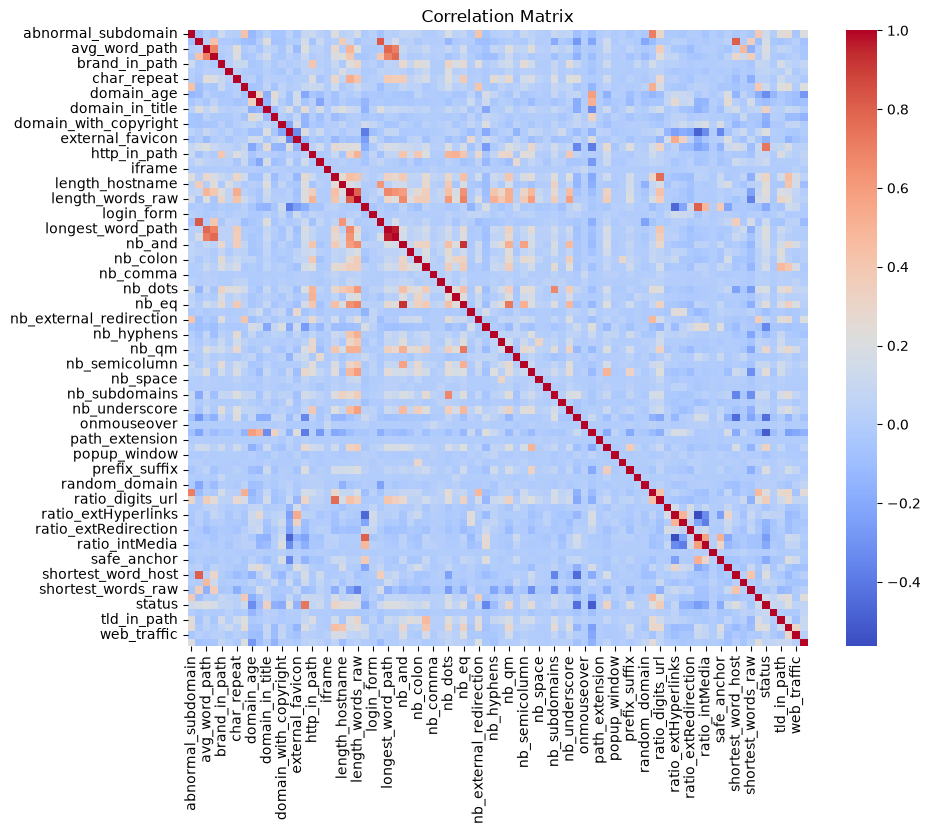

In [173]:
cleaned_data_frame_1 = generate_sub_data_frame(
    RELEVANT_FEATURES
)

frame_correlation_matrix(cleaned_data_frame_1, annotate=False)

#### Highly Correlated Pairings

The table lists the feature pairs that exceed the profiling correlation threshold. Each row identifies two columns carrying closely related information and serves as the input for the subsequent redundancy decision.

In [174]:
pd.DataFrame(
    get_highly_correlated_pairs(cleaned_data_frame_1),
    columns=["x", "y"]
)

,x,y
0,shortest_word_host,avg_word_host
1,avg_word_host,longest_word_host
2,length_words_raw,length_url
3,longest_word_path,longest_words_raw
4,nb_eq,nb_and
5,links_in_tags,ratio_intHyperlinks


#### Redundant Feature Inference from Correlation

For each highly correlated pair, the workflow compares the features' relationships with the `status` target. The feature with the weaker target association is treated as the more redundant representative, preserving the signal that is more relevant to classification while reducing duplication.

In [175]:
CORRELATED_REDUNDANT_FEATURES = get_redundant_correlated_features(cleaned_data_frame_1)

pd.DataFrame(
    CORRELATED_REDUNDANT_FEATURES,
    columns=["correlated_redundant_features"]
)

,correlated_redundant_features
0,longest_word_host
1,nb_and
2,length_words_raw
3,longest_words_raw
4,avg_word_host
5,links_in_tags


### Low Target-Correlation Features

Correlation with the target is used as a screening signal rather than as a complete measure of feature quality. Features whose absolute relationship with `status` falls below the profiling threshold are listed separately because they contribute little direct evidence for the classification task.

This criterion complements the constant-value and pairwise-correlation checks; it does not claim that a low-correlation feature is universally useless in every model.

In [176]:
LOW_TARGET_CORRELATION_FEATURES = get_low_target_correlation_features(cleaned_data_frame_1)

pd.DataFrame(
    LOW_TARGET_CORRELATION_FEATURES,
    columns=["low_target_correlation_features"]
)

,low_target_correlation_features
0,onmouseover
1,right_clic
2,iframe
3,nb_space
4,path_extension


### All Redundant Features

The combined table below consolidates every feature removed by the profiling rules and records the reason for each decision. Keeping the reason alongside the feature name makes the reduction process transparent and easier to review.

In [ ]:
# Prevents reasoning from being truncated
pd.set_option('display.max_colwidth', None)

df = pd.concat(
    [
        feature_reason_table(
            CONSTANT_REDUNDANT_FEATURES,
            "constant value across the dataset"
        ),
        feature_reason_table(
            CORRELATED_REDUNDANT_FEATURES,
            "lower target correlation within a highly correlated pair"
        ),
        feature_reason_table(
            LOW_TARGET_CORRELATION_FEATURES,
            "absolute target correlation below the profiling threshold"
        ),
    ],
    ignore_index=True,
).sort_values("feature").reset_index().drop(columns=["index"])

df

,feature,reason
0,avg_word_host,lower target correlation within a highly correlated pair
1,iframe,absolute target correlation below the profiling threshold
2,length_words_raw,lower target correlation within a highly correlated pair
3,links_in_tags,lower target correlation within a highly correlated pair
4,longest_word_host,lower target correlation within a highly correlated pair
5,longest_words_raw,lower target correlation within a highly correlated pair
6,nb_and,lower target correlation within a highly correlated pair
7,nb_or,constant value across the dataset
8,nb_space,absolute target correlation below the profiling threshold
9,onmouseover,absolute target correlation below the profiling threshold


### Relevant Features

The remaining columns form the candidate feature set after constant, highly correlated, and low-target-correlation features have been removed. This list is the basis for the final correlation review below and is the feature context intended for downstream model generation.

In [178]:
REDUNDANT_FEATURES = (
    CONSTANT_REDUNDANT_FEATURES
    | CORRELATED_REDUNDANT_FEATURES
    | LOW_TARGET_CORRELATION_FEATURES
)

RELEVANT_FEATURES -= REDUNDANT_FEATURES

pd.DataFrame(RELEVANT_FEATURES, columns=["relevant_features"])

,relevant_features
0,status
1,https_token
2,shortening_service
3,empty_title
4,shortest_word_path
...,...
67,port
68,nb_semicolumn
69,nb_eq
70,nb_subdomains


## Clean Dataset Context

This final section revisits the reduced feature set after redundancy removal. The correlation matrix and follow-up tables show how much structure remains among the selected features and how strongly those features relate to the target.

The purpose is validation and interpretation: it confirms that the reduction process leaves a useful, non-constant set of signals while keeping the selected feature names visible for later model-building steps.

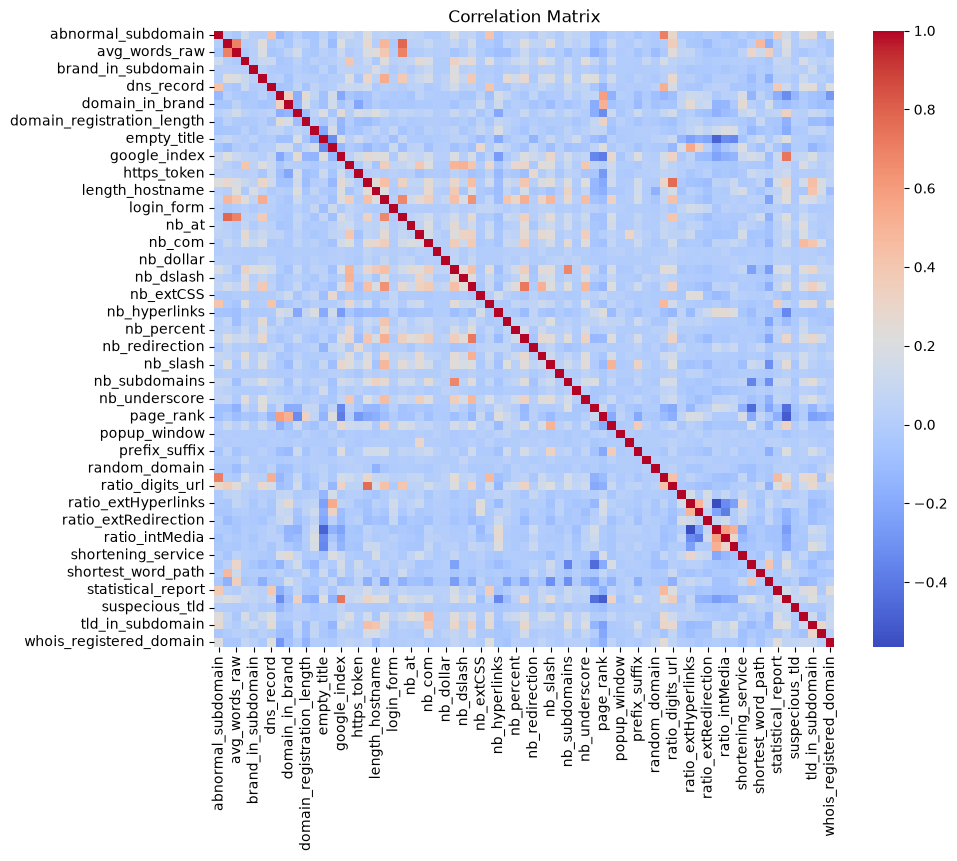

In [179]:
cleaned_data_frame_2 = generate_sub_data_frame(
    RELEVANT_FEATURES
)

frame_correlation_matrix(cleaned_data_frame_2, annotate=False)

In [180]:
get_top_correlation_pairs(cleaned_data_frame_2, 10)

,,correlation_value
avg_word_path,longest_word_path,0.783384
ip,ratio_digits_url,0.764657
status,google_index,0.734620
nb_eq,nb_qm,0.725301
ratio_digits_host,abnormal_subdomain,0.704427
avg_words_raw,avg_word_path,0.699656
longest_word_path,avg_words_raw,0.689232
nb_subdomains,nb_dots,0.678439
longest_word_path,length_url,0.675539
length_url,nb_eq,0.637347


In [181]:
corr_to_target_df = get_correlation_to_target(
    set(cleaned_data_frame_2.columns)
)
corr_to_target_df.drop(["status"], inplace=True)
corr_to_target_df.rename(columns={"status": "correlation_value"})

,correlation_value
google_index,0.734620
ratio_digits_url,0.354270
domain_in_title,0.335234
phish_hints,0.331244
ip,0.311288
...,...
ratio_intHyperlinks,-0.256211
domain_age,-0.323937
nb_hyperlinks,-0.342196
nb_www,-0.440457


<!-- FooterStart -->
---
[README on Documentation](README.md) | [Architecture Documentation](architecture/01_network_topology.md) | [Command Line Interface Documentation](cli.md)
<!-- FooterEnd -->